<a href="https://colab.research.google.com/github/LuizGustavoReis/am-t4-s1a2026/blob/main/NeuralizadorCensus0423.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline | Carregamento e Detecção de Anomalias [Fase 1 - census_data]

## Importar dados do Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Bibliotecas de Python

In [2]:
!pip -q install plotly
!pip -q install yellowbrick

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Carregar digest de base_credit

In [4]:
import pickle

In [25]:
with open('/content/drive/MyDrive/am-t4/census.pkl', 'rb') as f:
 X_census_treinameto , Y_census_treinamento, X_census_teste, Y_census_teste = pickle.load(f)

In [27]:
X_census_treinameto.shape, Y_census_treinamento.shape

((27676, 108), (27676,))

In [28]:
X_census_teste.shape, Y_census_teste.shape

((4885, 108), (4885,))

In [8]:
from sklearn.naive_bayes import GaussianNB

In [35]:
naive_census_data = GaussianNB()
naive_census_data.fit(X_census_treinameto, Y_census_treinamento)

GaussianNB()

## Criando base Previsora

In [36]:
census_predict = naive_census_data.predict(X_census_teste)

In [42]:
census_predict

array([10, 13, 12, ..., 10, 13, 13])

In [43]:
Y_census_teste

array([10, 13, 12, ..., 10, 13, 13])

In [44]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [45]:
accuracy_score(Y_census_teste, census_predict)


0.996315250767656

In [46]:
confusion_matrix(Y_census_teste, census_predict)

array([[   7,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0],
       [   0,   23,    0,    0,    0,    0,    0,    0,    1,    0,    0,
           0,    0,    0,    0,    0],
       [   0,    0,   49,    0,    0,    0,    0,    0,    1,    0,    0,
           0,    0,    0,    0,    0],
       [   0,    0,    0,   91,    0,    0,    0,    0,    1,    0,    0,
           0,    0,    0,    0,    0],
       [   0,    0,    0,    0,   71,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0],
       [   0,    0,    0,    0,    0,  137,    0,    0,    2,    0,    0,
           0,    0,    0,    0,    0],
       [   0,    0,    0,    0,    0,    0,  185,    0,    1,    0,    0,
           0,    0,    0,    0,    0],
       [   0,    0,    0,    0,    0,    0,    0,   56,    0,    0,    0,
           0,    0,    0,    0,    0],
       [   0,    0,    0,    0,    0,    0,    0,    0, 1546,    0,    0,
           0,    0,   

In [47]:
from yellowbrick.classifier import ConfusionMatrix


0.996315250767656

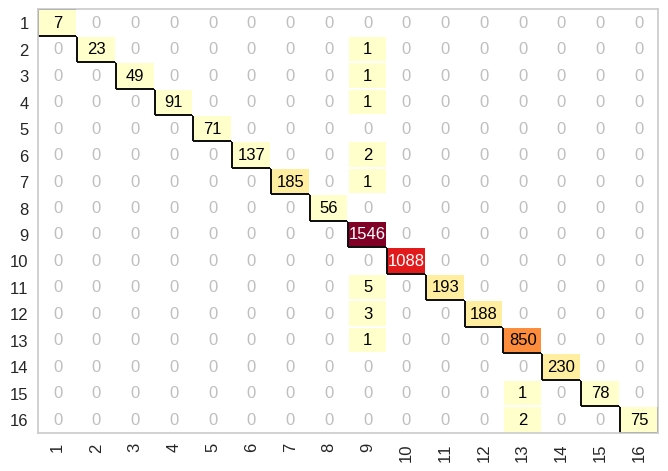

In [48]:
cm_credit = ConfusionMatrix(naive_census_data)
cm_credit.fit(X_census_treinameto, Y_census_treinamento)
cm_credit.score(X_census_teste, Y_census_teste)

#